# Système de recommandation — Approche Content-Based

Principe : recommander à un utilisateur des articles dont les embeddings sont proches de ceux qu'il a déjà cliqués.

Étapes :
1. Chargement des données
2. Réduction de dimension des embeddings (PCA)
3. Calcul de profil utilisateur
4. Calcul de similarité cosinus
5. Génération des recommandations (top 5)
6. Évaluation

## 1. Chargement des données

In [1]:
import pickle
import numpy as np
import pandas as pd

DATA_DIR = "../news-portal-user-interactions-by-globocom"

clicks = pd.read_parquet(f"{DATA_DIR}/clicks_full.parquet")
articles_metadata = pd.read_csv(f"{DATA_DIR}/articles_metadata.csv")

with open(f"{DATA_DIR}/articles_embeddings.pickle", "rb") as f:
    embeddings_raw = pickle.load(f)

print("Clics :", clicks.shape)
print("Métadonnées :", articles_metadata.shape)
print("Embeddings :", embeddings_raw.shape)

Clics : (2988181, 12)
Métadonnées : (364047, 5)
Embeddings : (364047, 250)


## 2. Réduction de dimension des embeddings (PCA)

Les embeddings font 364 047 × 250 = 364 Mo. On réduit à 50 dimensions pour alléger le déploiement sur Azure tout en conservant l'essentiel de l'information sémantique.

**Pourquoi 50 ?** C'est un bon compromis entre compression et conservation de variance — on vérifiera le ratio de variance expliquée après la PCA.

In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=42)
embeddings_reduced = pca.fit_transform(embeddings_raw)

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance expliquée avec {N_COMPONENTS} composantes : {explained_variance:.2%}")
print(f"Shape après PCA : {embeddings_reduced.shape}")
print(f"Taille en mémoire (Mo) : {embeddings_reduced.nbytes / 1e6:.1f}")

Variance expliquée avec 50 composantes : 94.53%
Shape après PCA : (364047, 50)
Taille en mémoire (Mo) : 72.8


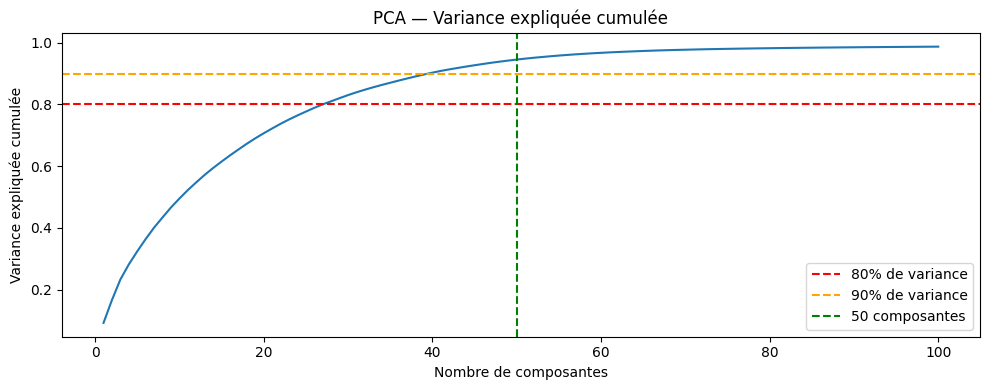

In [3]:
# Courbe de variance expliquée cumulée pour visualiser le bon nb de composantes
pca_full = PCA(n_components=100, random_state=42)
pca_full.fit(embeddings_raw)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 101), cumulative_variance)
ax.axhline(y=0.8, color="red", linestyle="--", label="80% de variance")
ax.axhline(y=0.9, color="orange", linestyle="--", label="90% de variance")
ax.axvline(x=N_COMPONENTS, color="green", linestyle="--", label=f"{N_COMPONENTS} composantes")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée cumulée")
ax.set_title("PCA — Variance expliquée cumulée")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Construction de l'index article_id => index embedding

Les embeddings sont stockés dans un tableau numpy indexé de 0 à N. On a besoin d'un mapping entre `article_id` et la position dans ce tableau.

In [4]:
article_ids = articles_metadata["article_id"].values
article_id_to_index = {article_id: idx for idx, article_id in enumerate(article_ids)}

print(f"{len(article_id_to_index)} articles indexés")
print("Exemple :", list(article_id_to_index.items())[:3])

364047 articles indexés
Exemple : [(np.int64(0), 0), (np.int64(1), 1), (np.int64(2), 2)]


## 4. Profil utilisateur

Le profil d'un utilisateur est la **moyenne des embeddings** des articles qu'il a cliqués. C'est un vecteur unique qui résume ses centres d'intérêt dans l'espace sémantique.

Pourquoi la moyenne des embeddings ?

chaque article étant un point dans un espace à 50 dimensions (après PCA), si un utilisateur a cliqué sur 3 articles, on a 3 points dans cet espace. La moyenne de ces 3 points donne un point central qui représente "le centre de gravité" des intérêts de cet utilisateur.

L'hypothèse implicite est que les goûts d'un utilisateur sont homogènes et qu'on peut les résumer en un seul vecteur moyen. C'est une simplification : un utilisateur qui lit à la fois du sport et de la politique aura un profil "entre les deux", ce qui peut donner des recommandations floues. C'est la limite connue de cette approche.

In [5]:
def build_user_profile(user_id: int, clicks_df: pd.DataFrame, embeddings: np.ndarray, article_id_to_index: dict) -> np.ndarray | None:
    """Build a user profile as the mean embedding of clicked articles.
    
    Args:
        user_id: The user identifier.
        clicks_df: DataFrame containing user-article click interactions.
        embeddings: Article embeddings matrix (n_articles, n_dims).
        article_id_to_index: Mapping from article_id to embedding row index.
    
    Returns:
        Mean embedding vector of shape (n_dims,), or None if no valid articles found.
    """
    user_clicks = clicks_df[clicks_df["user_id"] == user_id]["click_article_id"].values
    valid_indices = [article_id_to_index[aid] for aid in user_clicks if aid in article_id_to_index]
    
    if not valid_indices:
        return None
    
    return embeddings[valid_indices].mean(axis=0)

# Test sur un utilisateur exemple
sample_user_id = clicks["user_id"].iloc[0]
profile = build_user_profile(sample_user_id, clicks, embeddings_reduced, article_id_to_index)
print(f"Profil de l'utilisateur {sample_user_id} : shape={profile.shape}")

Profil de l'utilisateur 0 : shape=(50,)


## 5. Recommandations par similarité cosinus

On calcule la similarité entre le profil utilisateur et tous les embeddings d'articles. On exclut les articles déjà cliqués et on retourne le top 5.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_articles_content_based(
    user_id: int,
    clicks_df: pd.DataFrame,
    embeddings: np.ndarray,
    article_ids: np.ndarray,
    article_id_to_index: dict,
    top_n: int = 5
) -> list[int]:
    """Recommend articles based on cosine similarity with the user profile.
    
    Args:
        user_id: The user identifier.
        clicks_df: DataFrame containing user-article click interactions.
        embeddings: Article embeddings matrix (n_articles, n_dims).
        article_ids: Array of article identifiers aligned with embeddings rows.
        article_id_to_index: Mapping from article_id to embedding row index.
        top_n: Number of recommendations to return.
    
    Returns:
        List of recommended article_ids.
    """
    user_profile = build_user_profile(user_id, clicks_df, embeddings, article_id_to_index)
    
    if user_profile is None:
        return []
    
    similarities = cosine_similarity([user_profile], embeddings)[0]
    
    already_clicked = set(clicks_df[clicks_df["user_id"] == user_id]["click_article_id"].values)
    
    ranked_indices = np.argsort(similarities)[::-1]
    recommendations = [
        int(article_ids[idx])
        for idx in ranked_indices
        if article_ids[idx] not in already_clicked
    ][:top_n]
    
    return recommendations

# Test
reco = recommend_articles_content_based(
    sample_user_id, clicks, embeddings_reduced, article_ids, article_id_to_index
)
print(f"Top 5 recommandations pour l'utilisateur {sample_user_id} :")
print(reco)

Top 5 recommandations pour l'utilisateur 0 :
[161133, 162235, 107637, 161789, 159495]


## 6. Évaluation — Top 5 recommandations / Precision@5

On évalue le modèle en **leave-one-out** : pour chaque utilisateur, on cache le dernier article cliqué, on génère des recommandations, et on vérifie la pertinence de la reco en regardant si l'article caché est dans le top 5.

l'évaluation en leave-one-out a une réponse en 0 ou 1 par utilisateur (l'article caché est dedans ou pas).

* 500 utilisateurs

On a 322 897 utilisateurs éligibles. 500 est un échantillon statistiquement représentatif pour estimer la precision@5 — l'erreur d'estimation reste faible. C'est un choix pragmatique pour l'évaluation offline.

In [8]:
def evaluate_content_based(
    clicks_df: pd.DataFrame,
    embeddings: np.ndarray,
    article_ids: np.ndarray,
    article_id_to_index: dict,
    n_users: int = 500,
    top_n: int = 5
) -> float:
    """Evaluate content-based recommendations using leave-one-out precision@N.
    
    Args:
        clicks_df: DataFrame containing user-article click interactions.
        embeddings: Article embeddings matrix (n_articles, n_dims).
        article_ids: Array of article identifiers aligned with embeddings rows.
        article_id_to_index: Mapping from article_id to embedding row index.
        n_users: Number of users to sample for evaluation.
        top_n: Number of recommendations to generate.
    
    Returns:
        Precision@N score between 0 and 1.
    """
    # Garder uniquement les users avec au moins 3 clics (sinon leave-one-out non pertinent)
    user_click_counts = clicks_df.groupby("user_id").size()
    eligible_users = user_click_counts[user_click_counts >= 3].index.tolist()
    sampled_users = pd.Series(eligible_users).sample(n=min(n_users, len(eligible_users)), random_state=42).tolist()
    
    hits = 0
    for user_id in sampled_users:
        user_clicks = clicks_df[clicks_df["user_id"] == user_id]["click_article_id"].values
        test_article = user_clicks[-1]
        train_clicks = clicks_df[(clicks_df["user_id"] == user_id) & (clicks_df["click_article_id"] != test_article)]
        
        train_df = clicks_df[clicks_df["user_id"] != user_id]
        train_df = pd.concat([train_df, train_clicks])
        
        reco = recommend_articles_content_based(
            user_id, train_df, embeddings, article_ids, article_id_to_index, top_n
        )
        if test_article in reco:
            hits += 1
    
    precision = hits / len(sampled_users)
    print(f"Precision@{top_n} sur {len(sampled_users)} utilisateurs : {precision:.4f}")
    return precision

precision_cb = evaluate_content_based(clicks, embeddings_reduced, article_ids, article_id_to_index)

Precision@5 sur 500 utilisateurs : 0.0040


Score de 0.0040 — est-ce grave ?

C'est très faible (4 hits sur 500 users), mais pas surprenant pour un modèle content-based avec leave-one-out strict. Voici pourquoi :

On cherche à retrouver un article précis parmi 364 047 — c'est une tâche très difficile
Le leave-one-out suppose que le prochain clic d'un utilisateur sera similaire à ses clics passés, ce qui n'est pas toujours vrai (les gens explorent)
En pratique pour un système de recommandation, on évalue aussi la diversité et la pertinence perçue, pas uniquement la precision@5 exacte. Ce score servira surtout à comparer les approches entre elles (content-based vs CF) plutôt qu'à juger la qualité absolue.

**Rappel cours**

distinction importante entre évaluation offline et utilité réelle.

Ce que mesure le leave-one-out ici :

On cache le dernier article cliqué d'un utilisateur et on vérifie si notre modèle le retrouve dans le top 5. C'est une évaluation très stricte : on cherche à prédire exactement quel article précis l'utilisateur allait cliquer, parmi 364 047 candidats.


Pourquoi le score reste utile malgré tout

Le score de 0.0040 ne signifie pas que le système recommande n'importe quoi. Il signifie juste qu'il ne prédit pas le futur clic exact. Or dans la vraie vie :

Un utilisateur qui lit des articles de sport sera content de recevoir 5 articles de sport pertinents, même si ce ne sont pas exactement ceux qu'il aurait cliqués
La pertinence perçue est difficile à mesurer offline
Le vrai intérêt du score est qu'il sert uniquement à comparer les deux approches entre elles. Si le CF obtient 0.02 et le content-based 0.004, ça indique que le CF est relativement meilleur pour prédire le prochain clic. C'est une base de comparaison, pas un jugement absolu de qualité.